In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
import PIL

from bvhgs import device
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianCloud
from bvhgs.renderer import Renderer
from bvhgs.prefix_sum import prefix_sum
from bvhgs.radix_sort import radix_sort, numpy_sort
import pathlib

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
np.random.seed(0)

# Create Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_ply(pathlib.Path("../resources/scenes/truck/truck.ply"))
len(gaussians)

148916

# Load Module and Shader

In [4]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="tileHistogram", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
  ]
)

In [5]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="tileHistogram", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
      ]
    ),
  ],
  entry_points = []
)

# Build Slang Buffer and Camera Parameter

In [6]:
# Create a buffer for the Gaussian points.
gaussian_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [7]:
cam_rot_mat = np.array([
    [
        0.786188006401062,
        -0.01644204743206501,
        -0.6177687048912048
    ],
    [
        -0.028784452006220818,
        0.9975867867469788,
        -0.06318280845880508
    ],
    [
        0.6173167824745178,
        0.0674557015299797,
        0.7838174700737
    ]

])
cam_rot = quaternion.from_rotation_matrix(cam_rot_mat)
cam_pos = np.array([
      0.6305696964263916,
      0.13185331225395203,
      -0.4680609107017517
])

In [8]:
camera = Camera(
    rotation=glm.quat(quaternion.as_float_array(cam_rot)),
    position=glm.vec3(cam_pos),
    sensor_size=glm.uvec2(979, 546),
    focal_length=580,
    near_plane=0.001,
    far_plane=100
)
camera.to_slang()

{'_rotation': [0.03458228334784508,
  -0.3269485533237457,
  -0.0032672490924596786,
  -0.9444036483764648],
 '_translation': vec3( -0.203009, -0.0895939, 0.764751 ),
 '_sensorSize': uvec2( 979, 546 ),
 '_focalLength': 580,
 '_nearPlane': 0.001,
 '_farPlane': 100}

# Projection

## Dispatch Projection Kernel

In [9]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x1097bd248,
  size = 11913280,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 11.36 MB,
  label = 
)

In [10]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x1097bd248,
  size = 595664,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 581.70 kB,
  label = 
)

In [11]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x600002829080)

In [12]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [13]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.42141643, 0.6402342, 0.009770019}, 'covariance': {{3.1069412e-06, -1.0682709e-06}, {-1.0682709e-06, 9.378066e-06}}, 'color': {0.38482323, 0.39198205, 0.49217752}, 'opacity': 0.5294011235237122, 'cachedInvCov': {{334980, 38158.117}, {38158.117, 110978.44}}} [Gaussian2D]

## Cull Gaussians

In [14]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [15]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

98758

In [16]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x1097bd248,
  size = 7900640,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.53 MB,
  label = 
)

In [17]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [18]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.42141643, 0.6402342, 0.009770019}, 'covariance': {{3.1069412e-06, -1.0682709e-06}, {-1.0682709e-06, 9.378066e-06}}, 'color': {0.38482323, 0.39198205, 0.49217752}, 'opacity': 0.5294011235237122, 'cachedInvCov': {{334980, 38158.117}, {38158.117, 110978.44}}} [Gaussian2D]

# Tiling

In [19]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [20]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tiles,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x1097bd248,
  size = 395032,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 385.77 kB,
  label = 
)

In [21]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles": num_tile_buf
    }
)

In [22]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

176614

In [23]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x1097bd248,
  size = 2825824,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 2.69 MB,
  label = 
)

In [24]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [25]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [26]:
numpy_sort(gaussian_table_buf)

In [27]:
ker_tile_hist = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("tileHistogram")])
)

In [28]:
hist_buf = device.create_buffer(
    element_count=2**8,
    struct_type=program.reflection.g_tile_hist_atomic,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
# Compute the histogram of the Gaussian table.
ker_tile_hist.dispatch(
    thread_count=[num_table_entries, 1, 1],
    numEntries=num_table_entries,
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "g_tile_hist_atomic": hist_buf,
    },
)

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



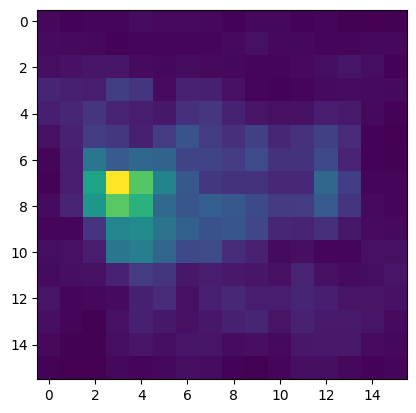

In [29]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [30]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [31]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x1097bd248,
  size = 14129120,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 13.47 MB,
  label = 
)

In [32]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [33]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [34]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [35]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [36]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target
    }
)

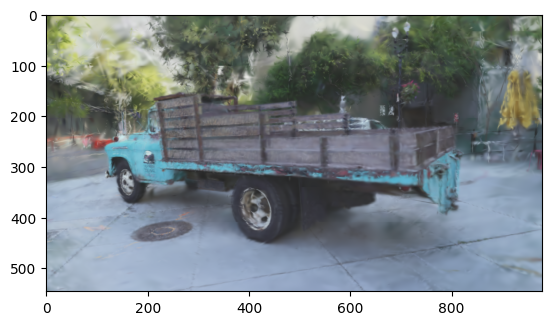

In [37]:
raw_image = render_target.to_numpy()
plt.imshow(raw_image)

# Integrate Renderer

In [38]:
# Create renderer
renderer = Renderer(gaussians, camera)

In [39]:
renderer.render()

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



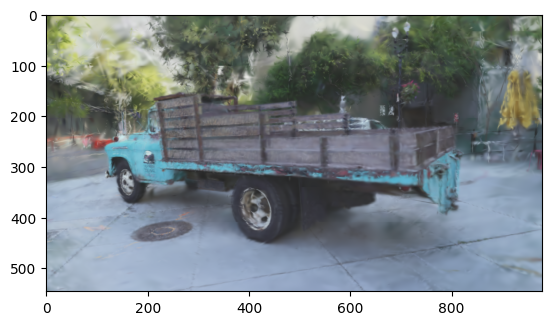

In [40]:
plt.imshow(renderer.render_target.to_numpy())

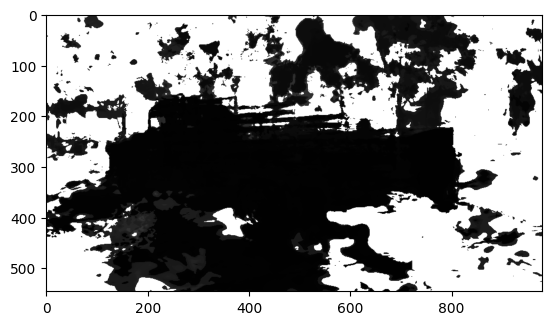

In [41]:
plt.imshow(renderer.depth_target.to_numpy())

In [42]:
%timeit renderer.render()

18.1 ms ± 290 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
